# Supplier Relationship Network Analysis
A manufacturing company wants to study the relationship network between its suppliers. 

You are given an Excel file that contains supplier connections. Each row shows:
- the supplier sending materials,
- the supplier receiving or forwarding materials,
- and the volume of transactions between them.

Using Python, pandas, NetworkX, and PyVis, answer the following:
1. Load the Excel file into Python.
2. Create a directed weighted graph from the dataset.
3. Print the list of nodes and edges.
4. Report the total number of nodes and edges in the network.
5. Compute the in-degree and out-degree of each supplier.
6. Compute the degree centrality and betweenness centrality of each supplier.
7. Identify:
   - the most connected supplier,
   - and the most important bridge supplier in the network.
8. Find the shortest path from Supplier_A to Supplier_L.
9. Create a basic network visualization using NetworkX.
10. Create an interactive visualization using PyVis, where node size reflects degree centrality and edge labels show transaction volume.

In [5]:
import pandas as pd     # Import pandas for data handling
import networkx as nx   # Import NetworkX for graph/network analysis

# Load the dataset from Excel file into a pandas DataFrame 
supplier_network = pd.read_excel("supplier_network.xlsx")


# Create directed weighted graph(Edges have direction)
DG = nx.DiGraph()


# Loop through each row of the dataframe and add nodes and edges to the graph
for index, row in supplier_network.iterrows(): 
    source_node = row["source_supplier"]                   # Supplier sending materials
    target_node = row["target_supplier"]                   # Supplier receiving materials
    weight = row["transaction_volume"]                     # Volume of transactions
    
    DG.add_edge(source_node, target_node, weight=weight)   # Add a directed edge with weight to the graph


# Print the list of nodes and edges
print("\nNodes:")
print(list(DG.nodes()))

print("\nEdges with weights:")
print(list(DG.edges(data=True)))


# Print the total number of nodes(suppliers) 
print("\nNumber of nodes:")
print(DG.number_of_nodes())

# Print the total number of edges(connections)
print("\nNumber of edges:")
print(DG.number_of_edges())


# Compute and print the in-degree and out-degree of each supplier 
print("\nIn-Degree and Out-Degree:")
for node in DG.nodes(): 
    print(
        node,
        "| In-Degree:", DG.in_degree(node),         # Number of incoming connections
        "| Out-Degree:", DG.out_degree(node)        # Number of outgoing connections
    )


# Compute the degree centrality and betweeness centrality of each supplier 
centrality = nx.degree_centrality(DG) 

print("\nDegree Centrality:")
for node, value in centrality.items():
    print(node, ":", round(value, 3))

betweenness = nx.betweenness_centrality(DG) 

print("\nBetweenness Centrality:")
for node, value in betweenness.items():
    print(node, ":", round(value, 3))


# Identify the most connected supplier in the network 
top_degree_supplier = max(centrality, key=centrality.get)

print("\nMost connected Supplier:") 
print(top_degree_supplier)

# Identify the most important bridge supplier in the network 
top_bridge_supplier = max(betweenness, key=betweenness.get)

print("\nMost important bridge Supplier:")
print(top_bridge_supplier)


# Find the shortest path from supplier_A to supplier_L
shortest_path = nx.shortest_path(DG, source="Supplier_A", target="Supplier_L")

print("\nShortest path from Supplier_A to Supplier_L:")
print(shortest_path)

# Compute length of the shortest path
shortest_path_length = nx.shortest_path_length(DG, source="Supplier_A", target="Supplier_L")

print("\nShortest path length:")
print(shortest_path_length)


Nodes:
['Supplier_A', 'Supplier_B', 'Supplier_C', 'Supplier_D', 'Supplier_E', 'Supplier_F', 'Supplier_G', 'Supplier_H', 'Supplier_I', 'Supplier_J', 'Supplier_K', 'Supplier_L']

Edges with weights:
[('Supplier_A', 'Supplier_B', {'weight': 150}), ('Supplier_A', 'Supplier_C', {'weight': 120}), ('Supplier_B', 'Supplier_D', {'weight': 130}), ('Supplier_B', 'Supplier_E', {'weight': 90}), ('Supplier_C', 'Supplier_D', {'weight': 140}), ('Supplier_C', 'Supplier_F', {'weight': 100}), ('Supplier_D', 'Supplier_G', {'weight': 160}), ('Supplier_D', 'Supplier_H', {'weight': 80}), ('Supplier_E', 'Supplier_H', {'weight': 110}), ('Supplier_E', 'Supplier_I', {'weight': 95}), ('Supplier_F', 'Supplier_I', {'weight': 85}), ('Supplier_G', 'Supplier_J', {'weight': 170}), ('Supplier_G', 'Supplier_K', {'weight': 75}), ('Supplier_H', 'Supplier_J', {'weight': 105}), ('Supplier_I', 'Supplier_L', {'weight': 180}), ('Supplier_J', 'Supplier_L', {'weight': 125}), ('Supplier_K', 'Supplier_L', {'weight': 115})]

Number

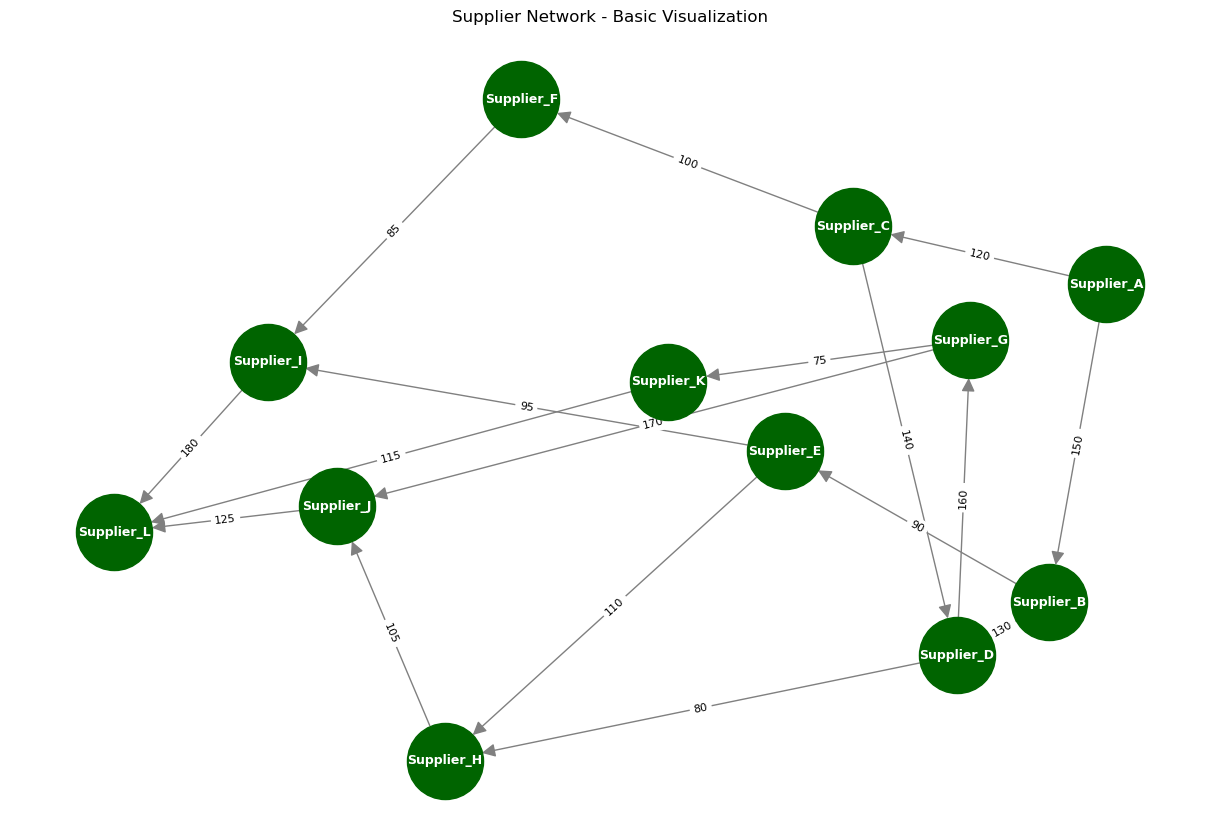

In [6]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt   

# Generate positions for nodes using spring layout  
pos = nx.spring_layout(DG, seed=42)

# Extract edge weights for labeling edges
edge_labels = nx.get_edge_attributes(DG, "weight")

# Create figure with defined size 
plt.figure(figsize=(12, 8))

# Draw graph with styling options
nx.draw(
    DG,
    pos,
    with_labels=True,         # Show node labels
    node_color="darkgreen",
    node_size=3000,
    font_size=9,
    font_color="white",
    font_weight="bold",
    edge_color="gray",
    arrows=True,              # Show direction of edges
    arrowsize=20
)

# Draw edge labels (transaction volumes)
nx.draw_networkx_edge_labels(
    DG,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

# Add title to the plot
plt.title("Supplier Network - Basic Visualization")

# Display the graph
plt.show()

In [ ]:
# Import PyVis for interactive visualization 
from pyvis.network import Network 

# Create an interactive network object
net = Network(
    height="700px",
    width="100%",
    directed=True,
    notebook=True,
    cdn_resources="in_line"
)

# Add nodes with size and tooltip information
for node in DG.nodes():
    net.add_node(
        node,
        label=node,
        size=20 + centrality[node] * 60,  # Node size based on degree centrality 
        title=(
            f"Node: {node}<br>"
            f"Degree Centrality: {round(centrality[node], 3)}<br>"
            f"Betweenness Centrality: {round(betweenness[node], 3)}<br>"
            f"In-Degree: {DG.in_degree(node)}<br>"
            f"Out-Degree: {DG.out_degree(node)}"
        )
    )

# Add edgeswith weights and labels 
for source, target, data in DG.edges(data=True):
    net.add_edge(
        source,
        target,
        value=data["weight"],
        label=str(data["weight"]),
        width=data["weight"]
    )

# Enable physics for dynamic layout
net.toggle_physics(True)

# Generate HTML content for the interactive graph
html_content = net.generate_html()

# Save HTML file using UTF-8 encoding
with open("supplier_network.html", "w", encoding="utf-8") as f:
    f.write(html_content)

# Print confirmation message
print("Interactive network saved as supplier_network_interactive.html")